# Evaluation — Part 2: supporting analyses

Derives diagnostic summaries from the stored inference records, including threshold, residual, and metadata-stratified analyses.


## 1. Environment and configuration

In [1]:
import sys
REPO = r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion"
sys.path.insert(0, REPO + r"\src\training")     # training_utils
sys.path.insert(0, REPO + r"\src\evaluation")   # evaluation_utils

import training_utils as tu
import evaluation_utils as eu

IMAGES_DIR = tu.REPO / "data" / "processed" / "images" / "evaluation"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

THR       = 0.30
TOL_S     = 0.50
UNLABELED = "negative"
TAGS      = ["phasenet_all", "eqtransformer_all", "eqcct_all", "gpd_all"]
THR_SWEEP = np.round(np.arange(0.05, 0.96, 0.05), 2)

payloads = eu.load_all(TAGS)
archs = list(payloads.keys())

  PhaseNet       tag=phasenet_all       15566 windows
  EQTransformer  tag=eqtransformer_all  15566 windows
  EQCCT          tag=eqcct_all          15566 windows
  GPD            tag=gpd_all            15566 windows


In [2]:
# Architecture used for the breakdown in section 5.
# Change it to look at another one; the CSV is overwritten with the chosen one.
AGG_ARCH = archs[0]
print("breakdown over:", AGG_ARCH)

breakdown over: PhaseNet


## 2. Precision-recall curves and AUC

Summarize precision and recall across the configured threshold grid to complement the fixed operating point.

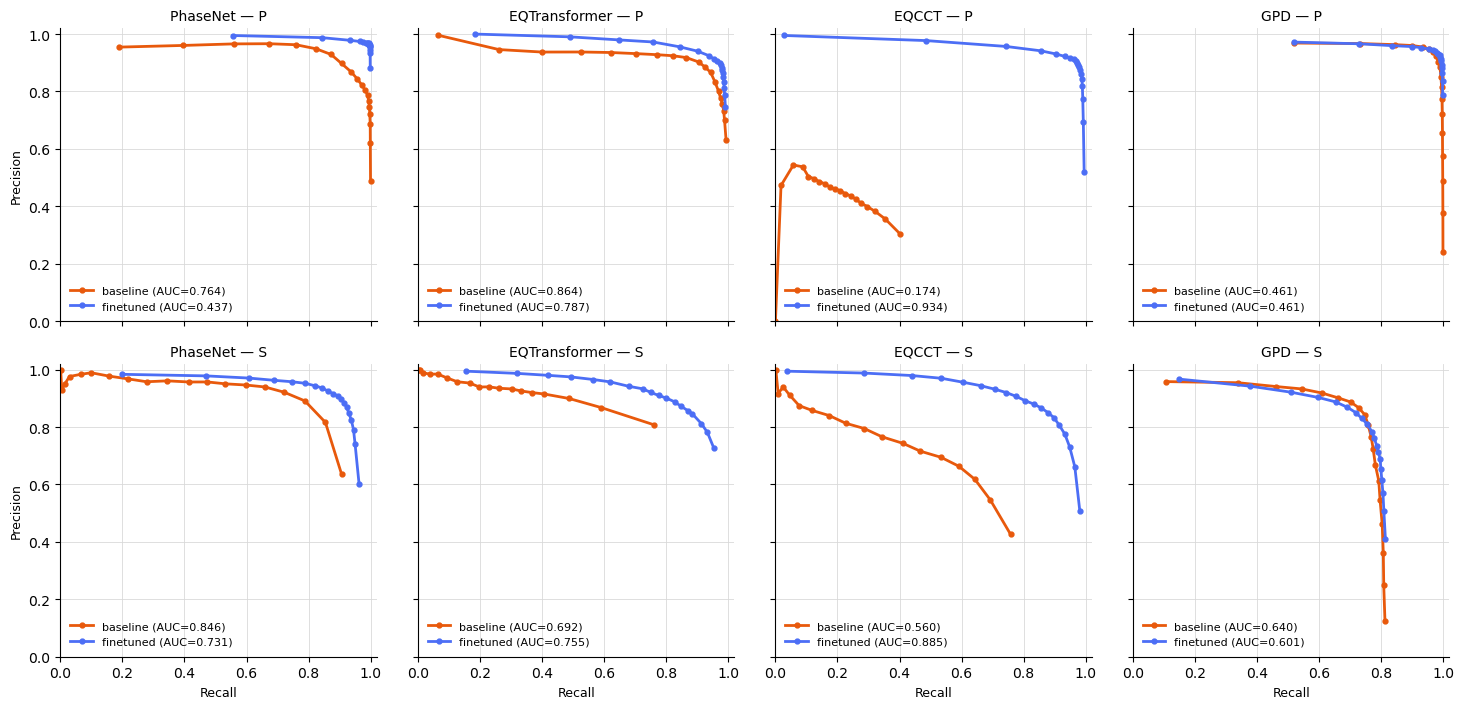

model                baseline  finetuned
architecture  phase                     
EQCCT         P         0.174      0.934
              S         0.560      0.885
EQTransformer P         0.864      0.787
              S         0.692      0.755
GPD           P         0.461      0.461
              S         0.640      0.601
PhaseNet      P         0.764      0.437
              S         0.846      0.731

In [3]:
fig, axes = plt.subplots(2, len(archs), figsize=(3.7 * len(archs), 7.2),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)
auc_rows, pr_rows = [], []

for j, arch in enumerate(archs):
    for i, ph in enumerate(("P", "S")):
        ax = axes[i][j]
        for (label, key), color in zip(eu.MODELS, (eu.COLOR_BASE, eu.COLOR_FT)):
            R, P, thrs = eu.pr_curve(payloads[arch][key], ph, THR_SWEEP, TOL_S,
                                     unlabeled=UNLABELED)
            auc = eu.pr_auc(R, P)
            auc_rows.append({"architecture": arch, "phase": ph, "model": label,
                             "PR_AUC": auc})
            for t, r_, p_ in zip(thrs, R, P):
                pr_rows.append({"architecture": arch, "phase": ph, "model": label,
                                "threshold": float(t), "recall": r_, "precision": p_})
            ax.plot(R, P, "-o", ms=3.5, lw=2, color=color,
                    label=f"{label} (AUC={auc:.3f})")
        ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
        ax.grid(color=eu.COLOR_GRID, lw=0.6); ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        ax.set_title(f"{arch} — {ph}", fontsize=10)
        ax.legend(frameon=False, fontsize=8, loc="lower left")
        if i == 1: ax.set_xlabel("Recall", fontsize=9)
        if j == 0: ax.set_ylabel("Precision", fontsize=9)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "p2_pr_curves.png", dpi=160, bbox_inches="tight")
plt.show()

auc_df = pd.DataFrame(auc_rows)
pd.DataFrame(pr_rows).to_csv(tu.RESULTS_DIR / "p2_pr.csv", index=False)
auc_df.to_csv(tu.RESULTS_DIR / "p2_auc.csv", index=False)
display(auc_df.pivot_table(index=["architecture", "phase"], columns="model",
                           values="PR_AUC").round(3))

## 3. Bootstrap intervals

Resample complete test windows with replacement to describe sampling variability for the chosen statistic.

In [4]:
N_BOOT = 1000     # final version

rows = []
for arch in archs:
    for label, key in eu.MODELS:
        recs = payloads[arch][key]
        for ph in ("P", "S"):
            for name, fn in (
                ("recall", lambda r, ph=ph: eu.evaluate(r, THR, TOL_S, unlabeled=UNLABELED)[ph].recall),
                ("F2",     lambda r, ph=ph: eu.evaluate(r, THR, TOL_S, unlabeled=UNLABELED)[ph].f2),
                ("medae_ms", lambda r, ph=ph: eu.timing_stats(
                    eu.evaluate(r, THR, TOL_S, unlabeled=UNLABELED)[ph].residuals_ms)["medae_ms"]),
            ):
                ci = eu.bootstrap_ci(recs, fn, n_boot=N_BOOT)
                rows.append({"architecture": arch, "model": label, "phase": ph,
                             "metric": name, "mean": ci["mean"],
                             "ci_low": ci["ci_low"], "ci_high": ci["ci_high"]})

boot = pd.DataFrame(rows)
boot.to_csv(tu.RESULTS_DIR / "p2_bootstrap.csv", index=False)
for ph in ("P", "S"):
    print(f"\nPHASE {ph}  (95% CI, {N_BOOT} resamples)")
    print(boot[boot.phase == ph].round(3).to_string(index=False))


PHASE P  (95% CI, 1000 resamples)
 architecture     model phase   metric   mean  ci_low  ci_high
     PhaseNet  baseline     P   recall  0.993   0.992    0.995
     PhaseNet  baseline     P       F2  0.938   0.935    0.941
     PhaseNet  baseline     P medae_ms 26.675  20.000   30.000
     PhaseNet finetuned     P   recall  0.997   0.996    0.998
     PhaseNet finetuned     P       F2  0.989   0.988    0.991
     PhaseNet finetuned     P medae_ms 20.000  20.000   20.000
EQTransformer  baseline     P   recall  0.969   0.965    0.973
EQTransformer  baseline     P       F2  0.930   0.926    0.934
EQTransformer  baseline     P medae_ms 30.000  30.000   30.000
EQTransformer finetuned     P   recall  0.982   0.979    0.985
EQTransformer finetuned     P       F2  0.956   0.953    0.959
EQTransformer finetuned     P medae_ms 40.000  40.000   40.000
        EQCCT  baseline     P   recall  0.259   0.249    0.269
        EQCCT  baseline     P       F2  0.281   0.270    0.291
        EQCCT  basel

## 4. Paired comparisons

The baseline and fine-tuned versions share the same windows. McNemar compares detection outcomes; Wilcoxon compares absolute residuals only where both versions detect the reference arrival.

In [5]:
rows = []
for arch in archs:
    for ph in ("P", "S"):
        mc = eu.mcnemar(payloads[arch]["baseline"], payloads[arch]["finetuned"],
                        ph, THR, TOL_S, unlabeled=UNLABELED)
        wx = eu.wilcoxon_abs(payloads[arch]["baseline"], payloads[arch]["finetuned"],
                             ph, THR, TOL_S, unlabeled=UNLABELED)
        rows.append({
            "architecture": arch, "phase": ph,
            "only baseline hits": mc["only_baseline"],
            "only fine-tuned hits": mc["only_finetuned"],
            "McNemar p": mc["p"],
            "n common": wx["n"],
            "|dt| median baseline (ms)": wx["median_baseline_ms"],
            "|dt| median fine-tuned (ms)": wx["median_finetuned_ms"],
            "Wilcoxon p": wx["p"]})

tests = pd.DataFrame(rows)
tests.to_csv(tu.RESULTS_DIR / "p2_paired_tests.csv", index=False)
display(tests.round(4))

print("\nReading: 'only fine-tuned hits' >> 'only baseline hits' with a small p means")
print("the fine-tuning recovers phases the original model was missing, not the reverse.")

,architecture,phase,only baseline hits,only fine-tuned hits,McNemar p,n common,|dt| median baseline (ms),|dt| median fine-tuned (ms),Wilcoxon p
0,PhaseNet,P,16,40,0.0018,7116,30.0,20.0,0.0000
1,PhaseNet,S,4,913,0.0000,1664,40.0,30.0,0.0000
2,EQTransformer,P,72,165,0.0000,6886,30.0,40.0,0.0000
3,EQTransformer,S,22,2608,0.0000,1651,40.0,40.0,0.0204
4,EQCCT,P,0,5220,0.0000,1857,30.0,10.0,0.0015
5,EQCCT,S,33,2196,0.0000,2315,60.0,30.0,0.0000
6,GPD,P,34,11,0.0008,7124,0.0,0.0,0.0000
7,GPD,S,31,44,0.1654,2181,60.0,50.0,0.0000



Reading: 'only fine-tuned hits' >> 'only baseline hits' with a small p means
the fine-tuning recovers phases the original model was missing, not the reverse.


## 5. Recall by distance and magnitude

Group reference arrivals by metadata intervals and report the count in each bin. Sparse intervals should be interpreted cautiously.

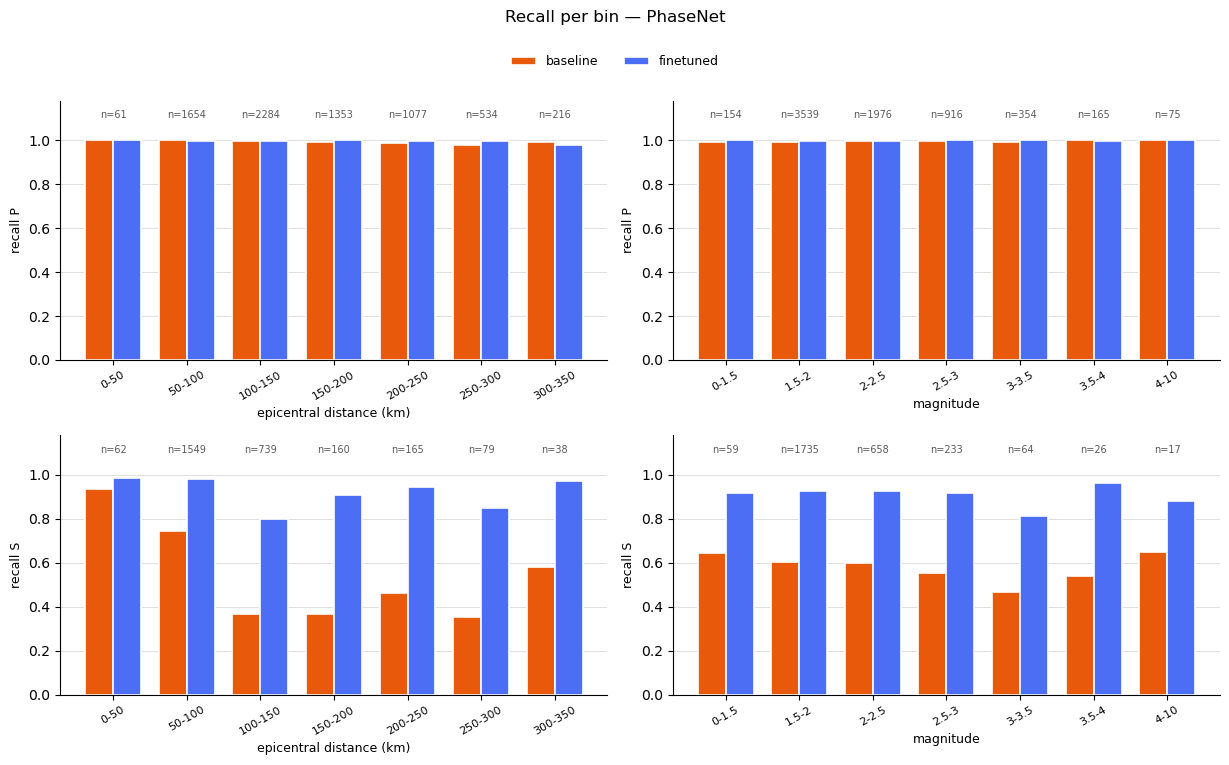

In [6]:
VARS = [("epicentral distance (km)", "distance", eu.BINS_DISTANCE),
        ("magnitude", "magnitude", eu.BINS_MAGNITUDE)]

rows = []
fig, axes = plt.subplots(2, len(VARS), figsize=(6.2 * len(VARS), 7.6))
axes = np.atleast_2d(axes)

for i, ph in enumerate(("P", "S")):
    for j, (name, key, edges) in enumerate(VARS):
        ax = axes[i][j]
        w = 0.38
        for k, ((label, pkey), color) in enumerate(
                zip(eu.MODELS, (eu.COLOR_BASE, eu.COLOR_FT))):
            df = eu.recall_by_bin(payloads[AGG_ARCH][pkey], ph, key, edges,
                                  thr=THR, tol_s=TOL_S, unlabeled=UNLABELED)
            for _, r in df.iterrows():
                rows.append({"architecture": AGG_ARCH, "phase": ph, "variable": key,
                             "model": label, **r.to_dict()})
            x = np.arange(len(df))
            ax.bar(x + (k - 0.5) * w, df["recall"].fillna(0), width=w,
                   color=color, label=label, edgecolor="white", linewidth=1.2)
            if k == 1:
                for xi, n in zip(x, df["n"]):
                    ax.text(xi, 1.09, f"n={n}", ha="center", va="bottom",
                            fontsize=7, color="0.35")
        ax.set_xticks(np.arange(len(df)), df["bin"], fontsize=8, rotation=30)
        ax.set_ylim(0, 1.18)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_ylabel(f"recall {ph}", fontsize=9)
        ax.set_xlabel(name, fontsize=9)
        ax.grid(axis="y", color=eu.COLOR_GRID, lw=0.6); ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)

# single figure-level legend, in its own band so it never overlaps the "n=" labels
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955),
           ncol=2, frameon=False, fontsize=9)
fig.suptitle(f"Recall per bin — {AGG_ARCH}", fontsize=12, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(IMAGES_DIR / f"p2_breakdown_{AGG_ARCH.lower()}.png",
            dpi=160, bbox_inches="tight")
plt.show()

pd.DataFrame(rows).to_csv(tu.RESULTS_DIR / "p2_breakdown.csv", index=False)

### 5.1. Export across architectures

Calculate the same binned recall for all four architectures and both phases.

In [ ]:
rows_all = []
for arch in archs:
    for ph in ("P", "S"):
        for name, key, edges in VARS:
            for label, pkey in eu.MODELS:
                df = eu.recall_by_bin(payloads[arch][pkey], ph, key, edges,
                                      thr=THR, tol_s=TOL_S, unlabeled=UNLABELED)
                for _, r in df.iterrows():
                    rows_all.append({"architecture": arch, "phase": ph,
                                     "variable": key, "model": label,
                                     **r.to_dict()})

breakdown_all = pd.DataFrame(rows_all)
breakdown_all.to_csv(tu.RESULTS_DIR / "p2_breakdown_all.csv", index=False)
print("saved:", tu.RESULTS_DIR / "p2_breakdown_all.csv")
breakdown_all[breakdown_all.phase == "P"].round(3)

### 5.2. Common S-wave set by distance and magnitude

Use the shared record indices with an S pseudo-arrival in the shorter evaluation window. Apply those indices to every architecture before computing the distance and magnitude breakdowns.

In [ ]:
common_idx = set(i for i, r in enumerate(payloads[archs[0]]["baseline"])
                  if r["true"]["S"] is not None)
print("conjunto comun (S):", len(common_idx))

rows_common = []
for arch in archs:
    for name, key, edges in VARS:
        for label, pkey in eu.MODELS:
            res = eu.evaluate(payloads[arch][pkey], THR, TOL_S, unlabeled=UNLABELED)["S"]
            hits = {i: h for i, h in res.hits if i in common_idx}
            idxs = list(hits.keys())
            hitsarr = np.array([hits[i] for i in idxs], dtype=float)
            recs = payloads[arch][pkey]
            vals = np.array([recs[i].get(key, np.nan) for i in idxs], dtype=float)
            for lo, hi in zip(edges[:-1], edges[1:]):
                m = (vals >= lo) & (vals < hi) & ~np.isnan(vals)
                rows_common.append({"architecture": arch, "phase": "S", "variable": key,
                                    "model": label, "bin": f"{lo:g}-{hi:g}",
                                    "n": int(m.sum()),
                                    "recall": float(hitsarr[m].mean()) if m.sum() else np.nan})

breakdown_common_s = pd.DataFrame(rows_common)
breakdown_common_s.to_csv(tu.RESULTS_DIR / "p2_breakdown_common_s.csv", index=False)
print("saved:", tu.RESULTS_DIR / "p2_breakdown_common_s.csv")
breakdown_common_s[breakdown_common_s.variable == "magnitude"].round(3)

### 5.3. Recall by signal-to-noise ratio

Group the stored phase-specific SNR values into intervals. P uses the full test set and S uses the common set; their SNR values describe different phase surroundings and should be read separately.

In [ ]:
BINS_SNR_P = [0, 6, 12, 18, np.inf]
BINS_SNR_S = [0, 6, 12, np.inf]

n_s_por_arch = {a: sum(1 for r in p["baseline"] if r["true"]["S"] is not None)
                for a, p in payloads.items()}
REF_ARCH = min(n_s_por_arch, key=n_s_por_arch.get)
COMMON_S = {r["trace_name"] for r in payloads[REF_ARCH]["baseline"]
            if r["true"]["S"] is not None}

def restrict_to_common(recs):
    return [r for r in recs
            if r["trace_name"] in COMMON_S
            or str(r.get("category", "")).lower() == "noise"]

rows_snr = []
for arch in archs:
    for label, key in eu.MODELS:
        for ph, col, edges, recs in (
                ("P", "snr_p", BINS_SNR_P, payloads[arch][key]),
                ("S", "snr_s", BINS_SNR_S, restrict_to_common(payloads[arch][key]))):
            df = eu.recall_by_bin(recs, ph, col, edges, thr=THR, tol_s=TOL_S,
                                  unlabeled=UNLABELED)
            for _, r in df.iterrows():
                rows_snr.append({"architecture": arch, "phase": ph, "variable": col,
                                 "model": label, **r.to_dict()})

snr_df = pd.DataFrame(rows_snr)
snr_df.to_csv(tu.RESULTS_DIR / "p2_breakdown_snr.csv", index=False)
print("guardado:", tu.RESULTS_DIR / "p2_breakdown_snr.csv")

for ph in ("P", "S"):
    print(f"\nFASE {ph} — sensibilidad por tramo de SNR (dB)")
    piv = (snr_df[snr_df.phase == ph]
           .pivot_table(index="bin", columns=["architecture", "model"],
                        values="recall", sort=False))
    n_por_bin = (snr_df[(snr_df.phase == ph) & (snr_df.model == "baseline")]
                 .drop_duplicates("bin").set_index("bin")["n"])
    print(piv.round(3).to_string())
    print("ventanas por tramo:", n_por_bin.to_dict())


### 5.4. S–P separation by distance

Compare median S–P separation in the common S set and the full available population within each distance interval.

In [ ]:
# Recompute required inputs when this cell is run independently.
if "n_s_por_arch" not in dir():
    n_s_por_arch = {a: sum(1 for r in p["baseline"] if r["true"]["S"] is not None)
                    for a, p in payloads.items()}
    REF_ARCH = min(n_s_por_arch, key=n_s_por_arch.get)

ARCH_CORTA = REF_ARCH                                    # ventana de 3.001 muestras
ARCH_LARGA = max(n_s_por_arch, key=n_s_por_arch.get)     # ventana de 6.000 muestras
corta = payloads[ARCH_CORTA]["baseline"]
larga = payloads[ARCH_LARGA]["baseline"]
print(f"ventana corta: {ARCH_CORTA}   ventana larga: {ARCH_LARGA}")

def _sp(recs, lo, hi):
    """Separacion S-P en segundos, para las ventanas de sismo del tramo dado."""
    return [(r["true"]["S"] - r["true"]["P"]) / 100
            for r in recs
            if str(r.get("category", "")).lower() == "earthquake"
            and r["true"]["P"] is not None and r["true"]["S"] is not None
            and lo <= r.get("distance", -1) < hi]

def _n_s(recs, lo, hi):
    return sum(1 for r in recs
               if str(r.get("category", "")).lower() == "earthquake"
               and r["true"]["S"] is not None
               and lo <= r.get("distance", -1) < hi)

tramos = list(zip(eu.BINS_DISTANCE[:-1], eu.BINS_DISTANCE[1:]))
tramos.append((150, np.inf))          # fila agregada citada en el texto

rows_sp = []
for lo, hi in tramos:
    d_c, d_f = _sp(corta, lo, hi), _sp(larga, lo, hi)
    n_c, n_f = _n_s(corta, lo, hi), _n_s(larga, lo, hi)
    rows_sp.append({
        "tramo_km": f"{lo:g}-{hi:g}",
        "n_S_comun": n_c, "n_S_completa": n_f,
        "conservado_S_%": 100 * n_c / n_f if n_f else np.nan,
        "n_both_comun": len(d_c), "n_both_completa": len(d_f),
        "mediana_S_P_comun_s": float(np.median(d_c)) if d_c else np.nan,
        "mediana_S_P_completa_s": float(np.median(d_f)) if d_f else np.nan})

sp_df = pd.DataFrame(rows_sp)
sp_df.to_csv(tu.RESULTS_DIR / "p2_sp_median_by_distance.csv", index=False)
print("guardado:", tu.RESULTS_DIR / "p2_sp_median_by_distance.csv")
display(sp_df.round(2))


## 6. Real and synthetic noise

Report false-alarm rates separately for real noise and phase-randomized surrogates. The two groups need not contain the same transient features.

In [7]:
frames = []
for arch in archs:
    for label, key in eu.MODELS:
        fa = eu.noise_false_alarms(payloads[arch][key], thr=THR)
        if fa.empty:
            continue
        fa.insert(0, "model", label)
        fa.insert(0, "architecture", arch)
        frames.append(fa)

if frames:
    noise = pd.concat(frames, ignore_index=True)
    noise.to_csv(tu.RESULTS_DIR / "p2_false_alarms.csv", index=False)
    display(noise.round(2))
    print("\nIf only the 'all' row shows up, the records carry no 'trace_synthetic':")
    print("re-run the collect_<arch>.ipynb notebooks, which add it.")

,architecture,model,noise_type,windows,FP_P_%,FP_S_%,FP_any_%
0,PhaseNet,baseline,synthetic,7783,21.97,0.00,21.97
1,PhaseNet,baseline,all,7783,21.97,0.00,21.97
2,PhaseNet,finetuned,synthetic,7783,0.45,0.04,0.49
3,PhaseNet,finetuned,all,7783,0.45,0.04,0.49
4,EQTransformer,baseline,synthetic,7783,12.04,0.00,12.04
5,EQTransformer,baseline,all,7783,12.04,0.00,12.04
6,EQTransformer,finetuned,synthetic,7783,5.06,0.01,5.06
7,EQTransformer,finetuned,all,7783,5.06,0.01,5.06
8,EQCCT,baseline,synthetic,7783,8.06,0.13,8.12
9,EQCCT,baseline,all,7783,8.06,0.13,8.12



If only the 'all' row shows up, the records carry no 'trace_synthetic':
re-run the collect_<arch>.ipynb notebooks, which add it.


## 7. Sensitivity to evaluation settings

Check how the reported metrics change with matching tolerance and treatment of missing phase labels.

In [8]:
rows = []
for arch in archs:
    for label, key in eu.MODELS:
        for tol in (0.10, 0.25, 0.50, 1.00):
            res = eu.evaluate(payloads[arch][key], THR, tol, unlabeled=UNLABELED)
            for ph in ("P", "S"):
                rows.append({"architecture": arch, "model": label, "phase": ph,
                             "tolerance_s": tol, "recall": res[ph].recall,
                             "precision": res[ph].precision, "F2": res[ph].f2})

tol_df = pd.DataFrame(rows)
tol_df.to_csv(tu.RESULTS_DIR / "p2_sensitivity_tolerance.csv", index=False)
display(tol_df.pivot_table(index=["architecture", "phase", "model"],
                           columns="tolerance_s", values="F2").round(3))

tolerance_s                     0.10   0.25   0.50   1.00
architecture  phase model                                
EQCCT         P     baseline   0.262  0.279  0.281  0.281
                    finetuned  0.867  0.944  0.958  0.961
              S     baseline   0.373  0.484  0.502  0.518
                    finetuned  0.728  0.860  0.884  0.894
EQTransformer P     baseline   0.845  0.924  0.930  0.931
                    finetuned  0.839  0.942  0.956  0.960
              S     baseline   0.330  0.378  0.382  0.382
                    finetuned  0.638  0.813  0.852  0.863
GPD           P     baseline   0.821  0.919  0.926  0.927
                    finetuned  0.921  0.973  0.975  0.975
              S     baseline   0.529  0.718  0.749  0.759
                    finetuned  0.610  0.759  0.773  0.778
PhaseNet      P     baseline   0.891  0.935  0.938  0.939
                    finetuned  0.951  0.988  0.989  0.990
              S     baseline   0.560  0.638  0.645  0.647
                    finetuned  0.787  0.896  0.912  0.917

### 7.2. Missing phase labels in earthquake windows

With `unlabeled="negative"`, peaks for an unlabelled phase count as false positives. With `unlabeled="ignore"`, that phase is excluded for those windows. This comparison documents the effect on precision.

In [9]:
rows = []
for arch in archs:
    for label, key in eu.MODELS:
        for crit in ("negative", "ignore"):
            res = eu.evaluate(payloads[arch][key], THR, TOL_S, unlabeled=crit)
            for ph in ("P", "S"):
                r = res[ph]
                rows.append({"architecture": arch, "model": label, "phase": ph,
                             "criterion": crit, "recall": r.recall,
                             "precision": r.precision, "F2": r.f2,
                             "FP": r.fp, "ignored windows": r.n_ignored})

sens = pd.DataFrame(rows)
sens.to_csv(tu.RESULTS_DIR / "p2_sensitivity_unlabeled.csv", index=False)
print("PHASE S — the criterion only affects precision")
display(sens[sens.phase == "S"].round(3))

PHASE S — the criterion only affects precision


,architecture,model,phase,criterion,recall,precision,F2,FP,ignored windows
1,PhaseNet,baseline,S,negative,0.597,0.947,0.645,94,0
3,PhaseNet,baseline,S,ignore,0.597,0.993,0.649,12,4991
5,PhaseNet,finetuned,S,negative,0.923,0.869,0.912,389,0
7,PhaseNet,finetuned,S,ignore,0.923,0.981,0.934,51,4991
9,EQTransformer,baseline,S,negative,0.333,0.926,0.382,134,0
11,EQTransformer,baseline,S,ignore,0.333,0.989,0.384,19,2757
13,EQTransformer,finetuned,S,negative,0.847,0.873,0.852,618,0
15,EQTransformer,finetuned,S,ignore,0.847,0.979,0.871,91,2757
17,EQCCT,baseline,S,negative,0.467,0.716,0.502,931,0
19,EQCCT,baseline,S,ignore,0.467,0.849,0.513,416,2757


## 8. Summary

These analyses complement the main metrics by showing threshold behavior, uncertainty, recording-condition breakdowns, and the effect of evaluation choices.